## 从 Wtie 成果构建时间域低频模型

这个 notebook 读取已经保存好的 7 口井井震标定成果（AI + 时深表），构建 `LfmTimeWell` 输入，调用 `lfm_time.py` 生成时间域低频模型，并做三维与剖面检查，同时导出 `npz` 和 `SEG-Y` 文件用于后续检查。


In [1]:
import json
import re
import sys
from pathlib import Path

import cigsegy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
if not (repo_root / "src").exists():
    raise RuntimeError("Could not locate repo root containing 'src'.")

src_root = repo_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from cup.petrel.load import (
    import_checkshots_petrel,
    import_interpretation_petrel,
    import_well_heads_petrel,
)
from cup.seismic.lfm_time import LfmTimeWell, build_lfm_time_model
from cup.seismic.process import TargetLayer, interpolate_interpretation_surface
from cup.seismic.survey import open_survey
from wtie.processing import grid

In [2]:
data_root = repo_root / "data"
lfm_output_dir = data_root / "output_lfm_time_from_wtie"
lfm_output_file = lfm_output_dir / "lfm_time_from_wtie.npz"
lfm_output_segy_file = lfm_output_dir / "lfm_time_from_wtie.segy"
# debug_dir = data_root / "_debug"
wtie_root = data_root / "output_vertical_well_wtie"
ai_dir = wtie_root / "ai"
tdtable_dir = wtie_root / "tdtable"
# wavelet_dir = wtie_root / "wavelet"  # 子波不参与低频模型构建

well_heads_file = data_root / "raw" / "well_heads"

seismic_file = data_root / "raw" / "mero se 0116_1ms_new_84_coord.Sgy"
segy_iline = 5
segy_xline = 21
segy_istep = 1
segy_xstep = 4

horizon_files = {
    "bve_top": data_root / "interpre_time" / "bve_top_t",
    "bve_bot": data_root / "interpre_time" / "bve_bot_t",
    "itp_bot": data_root / "interpre_time" / "itp_bot_t",
}

for path in [ai_dir, tdtable_dir, well_heads_file, seismic_file, *horizon_files.values()]:
    if not path.exists():
        raise FileNotFoundError(path)

wtie_root

WindowsPath('c:/Users/WangQinZhuo/Program/libra_workflow_standardize/data/output_vertical_well_wtie')

In [3]:
STEM_PATTERN = re.compile(r"^(?P<well_name>.+)_(?P<offset>-?\d+(?:\.\d+)?)$")


def parse_artifact_stem(stem: str) -> tuple[str, float]:
    match = STEM_PATTERN.match(stem)
    if match is None:
        raise ValueError(f"Unrecognized artifact stem: {stem}")
    return match.group("well_name"), float(match.group("offset"))


def collect_wtie_artifacts(ai_dir: Path, tdtable_dir: Path) -> pd.DataFrame:
    ai_map = {path.stem: path for path in sorted(ai_dir.glob("*.csv"))}
    tdt_map = {path.stem: path for path in sorted(tdtable_dir.glob("*.txt"))}

    common_stems = sorted(set(ai_map) & set(tdt_map))
    if not common_stems:
        raise ValueError("No paired AI/tdtable artifacts were found.")

    missing_ai = sorted(set(tdt_map) - set(ai_map))
    missing_tdt = sorted(set(ai_map) - set(tdt_map))
    if missing_ai:
        print("Stems missing AI:", missing_ai)
    if missing_tdt:
        print("Stems missing tdtable:", missing_tdt)

    records = []
    for stem in common_stems:
        well_name, interpretation_offset = parse_artifact_stem(stem)
        records.append(
            {
                "stem": stem,
                "well_name": well_name,
                "interpretation_offset": interpretation_offset,
                "ai_file": ai_map[stem],
                "tdtable_file": tdt_map[stem],
            }
        )

    return pd.DataFrame.from_records(records).sort_values(["well_name", "interpretation_offset"]).reset_index(drop=True)


def load_ai_log_from_csv(csv_file: Path) -> grid.Log:
    df = pd.read_csv(csv_file)
    required_cols = {"twt_s", "ai"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"AI CSV is missing columns {sorted(missing)}: {csv_file}")

    twt = df["twt_s"].to_numpy(dtype=float)
    ai = df["ai"].to_numpy(dtype=float)
    order = np.argsort(twt)
    twt = twt[order]
    ai = ai[order]
    return grid.Log(ai, twt, "twt", name="AI", allow_nan=False)


def build_target_layer(geometry: dict) -> TargetLayer:
    interpolated = {}
    for horizon_name, horizon_file in horizon_files.items():
        raw_df = import_interpretation_petrel(horizon_file)
        interp_df = interpolate_interpretation_surface(
            interpretation_df=raw_df,
            geometry=geometry,
            outlier_threshold=0.02,
            min_neighbor_count=2,
            keep_nan=True,
        )
        interpolated[horizon_name] = interp_df

    return TargetLayer(
        interpolated_horizon_dfs=interpolated,
        geometry=geometry,
        horizon_names=list(horizon_files.keys()),
        # debug_dir=debug_dir,
    )


def build_lfm_wells(artifact_df: pd.DataFrame, well_heads_df: pd.DataFrame) -> list[LfmTimeWell]:
    head_lookup = well_heads_df.copy()
    head_lookup["_name_norm"] = head_lookup["Name"].astype(str).str.strip()
    head_lookup = head_lookup.set_index("_name_norm", drop=False)

    wells = []
    for row in artifact_df.itertuples(index=False):
        if row.well_name not in head_lookup.index:
            raise KeyError(f"Well '{row.well_name}' not found in well heads file.")

        head = head_lookup.loc[row.well_name]
        ai_log = load_ai_log_from_csv(row.ai_file)  # type: ignore
        tdtable = import_checkshots_petrel(row.tdtable_file, depth_domain="tvdss")  # type: ignore

        wells.append(
            LfmTimeWell(
                well_name=row.well_name,  # type: ignore
                property_name="AI",
                property_log=ai_log,
                time_depth_table=tdtable,
                x=float(head["Surface X"]),
                y=float(head["Surface Y"]),
                metadata={
                    "artifact_stem": row.stem,
                    "interpretation_offset": float(row.interpretation_offset),  # type: ignore
                    "kb": float(head["Well datum value"]),
                },
            )
        )

    return wells

In [4]:
artifact_df = collect_wtie_artifacts(ai_dir=ai_dir, tdtable_dir=tdtable_dir)
well_heads_df = import_well_heads_petrel(well_heads_file)

print(f"Found {len(artifact_df)} paired wells.")
artifact_df

Found 7 paired wells.


,stem,well_name,interpretation_offset,ai_file,tdtable_file
0,2-ANP-2A-RJS_0.0,2-ANP-2A-RJS,0.000,c:\Users\WangQinZhuo\Program\libra_workflow_st...,c:\Users\WangQinZhuo\Program\libra_workflow_st...
1,L1-NW1_0.0,L1-NW1,0.000,c:\Users\WangQinZhuo\Program\libra_workflow_st...,c:\Users\WangQinZhuo\Program\libra_workflow_st...
2,L3-NW2A_0.012,L3-NW2A,0.012,c:\Users\WangQinZhuo\Program\libra_workflow_st...,c:\Users\WangQinZhuo\Program\libra_workflow_st...
3,L6-NW3A_0.012,L6-NW3A,0.012,c:\Users\WangQinZhuo\Program\libra_workflow_st...,c:\Users\WangQinZhuo\Program\libra_workflow_st...
4,L9-NW4A_0.0,L9-NW4A,0.000,c:\Users\WangQinZhuo\Program\libra_workflow_st...,c:\Users\WangQinZhuo\Program\libra_workflow_st...
5,NW11_0.03,NW11,0.030,c:\Users\WangQinZhuo\Program\libra_workflow_st...,c:\Users\WangQinZhuo\Program\libra_workflow_st...
6,NW7_0.036,NW7,0.036,c:\Users\WangQinZhuo\Program\libra_workflow_st...,c:\Users\WangQinZhuo\Program\libra_workflow_st...


In [5]:
survey = open_survey(
    seismic_file,
    seismic_type="segy",
    segy_options={
        "iline": segy_iline,
        "xline": segy_xline,
        "istep": segy_istep,
        "xstep": segy_xstep,
    },
)
geometry = survey.query_geometry(domain="time")
target_layer = build_target_layer(geometry)

print("Horizon names:", target_layer.horizon_names)
print("Zones:", target_layer.iter_zones())
geometry

100%|██████████| 361201/361201 [00:00<00:00, 1476709.02it/s]


Horizon names: ['bve_top', 'bve_bot', 'itp_bot']
Zones: [('bve_top', 'bve_bot'), ('bve_bot', 'itp_bot')]


{'n_il': 601,
 'inline_min': 1501.0,
 'inline_max': 2101.0,
 'inline_step': 1.0,
 'n_xl': 601,
 'xline_min': 4199.0,
 'xline_max': 6599.0,
 'xline_step': 4.0,
 'n_sample': 1201,
 'sample_min': 4.8,
 'sample_max': 6.0,
 'sample_step': 0.001000000000000334,
 'sample_domain': 'time',
 'sample_unit': 's'}

In [6]:
lfm_wells = build_lfm_wells(artifact_df, well_heads_df)

well_summary = pd.DataFrame(
    [
        {
            "well_name": well.well_name,
            "x": well.x,
            "y": well.y,
            "ai_samples": int(well.property_log.size),
            "twt_min": float(well.property_log.basis.min()),
            "twt_max": float(well.property_log.basis.max()),
            "tdt_samples": int(well.time_depth_table.size),
            "interpretation_offset": well.metadata.get("interpretation_offset"),  # type: ignore
        }
        for well in lfm_wells
    ]
)
well_summary

,well_name,x,y,ai_samples,twt_min,twt_max,tdt_samples,interpretation_offset
0,2-ANP-2A-RJS,779526.88,7278710.51,121,5.099424,5.339424,5775,0.000
1,L1-NW1,782033.00,7275558.00,83,4.968301,5.132301,3907,0.000
2,L3-NW2A,776850.00,7268698.00,119,5.067032,5.303032,5560,0.012
3,L6-NW3A,778537.00,7273461.00,117,5.083782,5.315782,5117,0.012
4,L9-NW4A,781898.00,7278121.00,110,5.059731,5.277731,5264,0.000
5,NW11,778190.00,7276407.00,94,5.170507,5.356507,4556,0.030
6,NW7,779813.00,7270613.00,63,5.034856,5.158856,3042,0.036


In [7]:
lfm_result = build_lfm_time_model(
    target_layer=target_layer,
    wells=lfm_wells,
    survey=survey,
    n_slices=20,
    variogram="spherical",
    exact=True,
    nugget=0.0,
)

print("volume shape:", lfm_result.volume.shape)
print("variance shape:", lfm_result.variance_volume.shape)
print("property:", lfm_result.metadata["property_name"])
print("zones:", lfm_result.metadata["zone_names"])
print("wells:", lfm_result.metadata["well_names"])

volume shape: (601, 601, 1201)
variance shape: (601, 601, 1201)
property: AI
zones: [['bve_top', 'bve_bot'], ['bve_bot', 'itp_bot']]
wells: ['2-ANP-2A-RJS', 'L1-NW1', 'L3-NW2A', 'L6-NW3A', 'L9-NW4A', 'NW11', 'NW7']


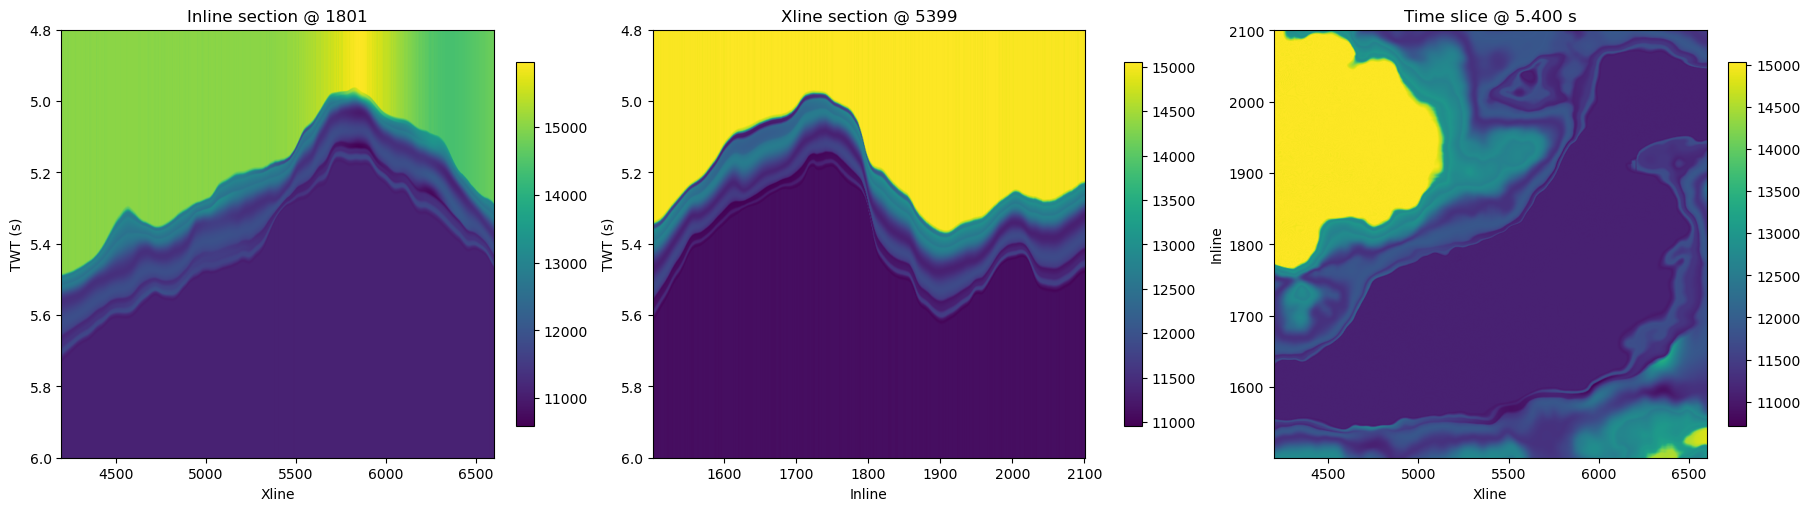

In [8]:
ilines = lfm_result.ilines
xlines = lfm_result.xlines
samples = lfm_result.samples
volume = lfm_result.volume

i_il = len(ilines) // 2
i_xl = len(xlines) // 2
i_t = len(samples) // 2

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

im0 = axes[0].imshow(
    volume[i_il, :, :].T,
    aspect="auto",
    origin="upper",
    extent=[xlines[0], xlines[-1], samples[-1], samples[0]],
    cmap="viridis",
)
axes[0].set_title(f"Inline section @ {ilines[i_il]:.0f}")
axes[0].set_xlabel("Xline")
axes[0].set_ylabel("TWT (s)")
fig.colorbar(im0, ax=axes[0], shrink=0.85)

im1 = axes[1].imshow(
    volume[:, i_xl, :].T,
    aspect="auto",
    origin="upper",
    extent=[ilines[0], ilines[-1], samples[-1], samples[0]],
    cmap="viridis",
)
axes[1].set_title(f"Xline section @ {xlines[i_xl]:.0f}")
axes[1].set_xlabel("Inline")
axes[1].set_ylabel("TWT (s)")
fig.colorbar(im1, ax=axes[1], shrink=0.85)

im2 = axes[2].imshow(
    volume[:, :, i_t],
    aspect="auto",
    origin="lower",
    extent=[xlines[0], xlines[-1], ilines[0], ilines[-1]],
    cmap="viridis",
)
axes[2].set_title(f"Time slice @ {samples[i_t]:.3f} s")
axes[2].set_xlabel("Xline")
axes[2].set_ylabel("Inline")
fig.colorbar(im2, ax=axes[2], shrink=0.85)

plt.show()

In [9]:
coverage_rows = []
for zone_name, zone_stats in lfm_result.coverage_stats["zones"].items():
    coverage_rows.append(
        {
            "zone": zone_name,
            "n_slices": len(zone_stats["slice_control_counts"]),
            "min_controls": int(np.min(zone_stats["slice_control_counts"])),
            "max_controls": int(np.max(zone_stats["slice_control_counts"])),
            "mean_controls": float(np.mean(zone_stats["slice_control_counts"])),
        }
    )

pd.DataFrame(coverage_rows)

,zone,n_slices,min_controls,max_controls,mean_controls
0,bve_top->bve_bot,20,2,7,6.1
1,bve_bot->itp_bot,20,1,7,5.3


In [10]:
lfm_output_dir.mkdir(parents=True, exist_ok=True)

np.savez_compressed(
    lfm_output_file,
    volume=lfm_result.volume.astype(np.float32),
    variance_volume=lfm_result.variance_volume.astype(np.float32),
    ilines=lfm_result.ilines,
    xlines=lfm_result.xlines,
    samples=lfm_result.samples,
    geometry_json=json.dumps(lfm_result.geometry, ensure_ascii=False),
    metadata_json=json.dumps(lfm_result.metadata, ensure_ascii=False),
    coverage_stats_json=json.dumps(lfm_result.coverage_stats, ensure_ascii=False),
)

lfm_volume_export = np.ascontiguousarray(lfm_result.volume.astype(np.float32))
keylocs = [segy_iline, segy_xline, segy_istep, segy_xstep]

def build_textual_header(title: str, lines: list[str]) -> str:
    rows = [f"C{idx:>2d} {text}"[:80].ljust(80) for idx, text in enumerate([title, *lines], start=1)]
    rows.extend([f"C{idx:>2d}".ljust(80) for idx in range(len(rows) + 1, 41)])
    textual = "".join(rows)
    if len(textual) != 3200:
        raise ValueError(f"Expected 3200-char textual header, got {len(textual)}")
    return textual


lfm_textual = build_textual_header(
    "WTIE low-frequency model volume",
    [
        f"artifact={lfm_output_file.name}",
        f"n_wells={len(lfm_wells)}",
        "n_slices=20 variogram=spherical",
        "exact=True nugget=0.0",
    ],
)

cigsegy.create_by_sharing_header(
    str(lfm_output_segy_file),
    str(seismic_file),
    lfm_volume_export,
    keylocs=keylocs,
    textual=lfm_textual,
)

print(f"Saved LFM artifact to: {lfm_output_file}")
print(f"Exported LFM SEG-Y to: {lfm_output_segy_file}")
lfm_output_segy_file

Saved LFM artifact to: c:\Users\WangQinZhuo\Program\libra_workflow_standardize\data\output_lfm_time_from_wtie\lfm_time_from_wtie.npz
Exported LFM SEG-Y to: c:\Users\WangQinZhuo\Program\libra_workflow_standardize\data\output_lfm_time_from_wtie\lfm_time_from_wtie.segy


WindowsPath('c:/Users/WangQinZhuo/Program/libra_workflow_standardize/data/output_lfm_time_from_wtie/lfm_time_from_wtie.segy')